<a href="https://colab.research.google.com/github/SRIKAR5139/Object_Detection_YOLOv3_EndSem_Lab_Exam_/blob/main/Object_Detection_YOLOv3_EndSem_Lab_Exam_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

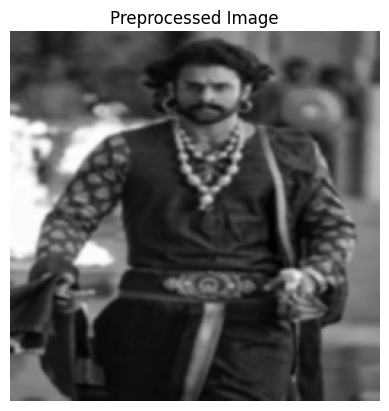

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('/content/Screenshot 2026-04-20 111920.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize
img = cv2.resize(img, (256, 256))

# Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Normalize
norm = gray / 255.0

# Filtering
blur = cv2.GaussianBlur(gray, (5,5), 0)

# Show
plt.imshow(blur, cmap='gray')
plt.title("Preprocessed Image")
plt.axis('off')

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

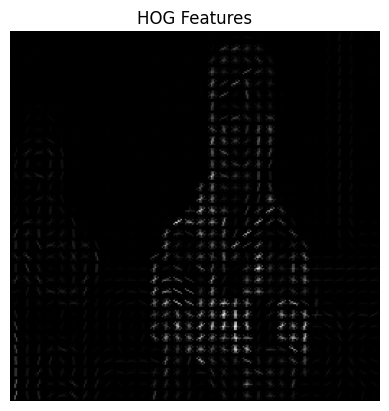

In [ ]:
from skimage.feature import hog
from skimage import exposure

# HOG
features, hog_image = hog(gray, pixels_per_cell=(8,8),
                          cells_per_block=(2,2),
                          visualize=True)

# Display
plt.imshow(hog_image, cmap='gray')
plt.title("HOG Features")
plt.axis('off')

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

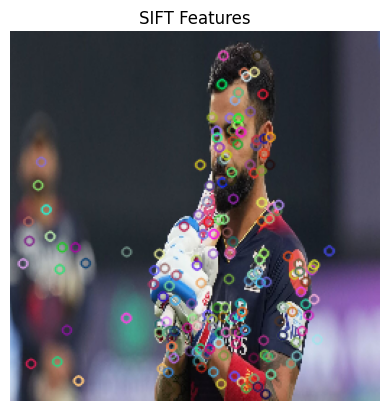

In [ ]:
# SIFT
sift = cv2.SIFT_create()
kp, des = sift.detectAndCompute(gray, None)

# Draw keypoints
img_sift = cv2.drawKeypoints(img, kp, None)

plt.imshow(img_sift)
plt.title("SIFT Features")
plt.axis('off')

File ‘yolov3.cfg’ already there; not retrieving.

File ‘yolov3.weights’ already there; not retrieving.

File ‘coco.names’ already there; not retrieving.



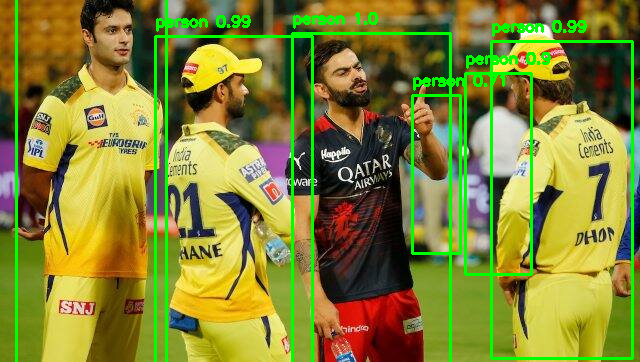

In [11]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Download YOLO files
!wget -nc https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg
!wget -nc https://pjreddie.com/media/files/yolov3.weights
!wget -nc https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names

# Load YOLO model
net = cv2.dnn.readNet("yolov3.weights", "yolov3.cfg")

# Load class labels
with open("coco.names", "r") as f:
    classes = f.read().strip().split("\n")

# Load image
img = cv2.imread("/content/Virat-Kohli-MS-Dhoni.jpg")
height, width = img.shape[:2]

# Preprocess image
blob = cv2.dnn.blobFromImage(img, 1/255, (416, 416), swapRB=True)
net.setInput(blob)

# Forward pass
layer_names = net.getUnconnectedOutLayersNames()
outputs = net.forward(layer_names)

boxes = []
confidences = []
class_ids = []

for out in outputs:
    for det in out:
        scores = det[5:]
        class_id = np.argmax(scores)
        confidence = scores[class_id]

        if confidence > 0.7 and classes[class_id] == "person":
            cx, cy, w, h = (det[0:4] * [width, height, width, height]).astype("int")
            x = int(cx - w / 2)
            y = int(cy - h / 2)

            boxes.append([x, y, int(w), int(h)])
            confidences.append(float(confidence))
            class_ids.append(class_id)

# Stronger NMS
indexes = cv2.dnn.NMSBoxes(boxes, confidences, 0.7, 0.3)

# Draw final bounding boxes
if len(indexes) > 0:
    for i in indexes:
        i = i[0] if isinstance(i, (list, tuple)) else i
        x, y, w, h = boxes[i]

        label = str(classes[class_ids[i]])
        conf = str(round(confidences[i], 2))

        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(img, label + " " + conf, (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# Show output
cv2_imshow(img)
cv2.waitKey(0)
cv2.destroyAllWindows()